## 1. Import Required Libraries

In [19]:

import os
import warnings
import logging
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

# Create directories used by the project
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# Configure logging
logging.basicConfig(
    filename="logs/model_training.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

In [20]:

# Update this path if your CSV file is stored elsewhere
DATA_PATH = "04_jzd_sales_data.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}. "
        "Place the CSV file in the same folder as this notebook or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

logging.info("Dataset loaded successfully. Shape: %s", df.shape)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (500, 9)


,lead_id,industry,service,lead_source,budget_inr,first_response_hours,followup_count,converted,days_to_conversion
0,1,CA/Accounting,Automation,Referral,25000,7,3,0,NaN
1,2,Retail,Chatbot,Email,35000,11,4,0,NaN
2,3,Manufacturing,Training/Courses,Instagram,150000,10,2,1,13.0
3,4,Logistics,AI/ML Solution,Referral,25000,8,4,0,NaN
4,5,Professional Services,Mobile App,Instagram,15000,8,2,1,4.0


## 3. Data Validation

In [21]:

required_columns = {
    "lead_id",
    "industry",
    "service",
    "lead_source",
    "budget_inr",
    "first_response_hours",
    "followup_count",
    "converted",
    "days_to_conversion"
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

# Validate target values
if not set(df["converted"].dropna().unique()).issubset({0, 1}):
    raise ValueError("Target column 'converted' must contain only 0 and 1.")

# Validate numeric columns
numeric_columns_to_validate = [
    "budget_inr",
    "first_response_hours",
    "followup_count"
]

for col in numeric_columns_to_validate:
    if (df[col] < 0).any():
        raise ValueError(f"Negative values found in {col}.")

print("Data validation completed successfully.")
print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
print("Duplicate Lead IDs:", df["lead_id"].duplicated().sum())


Data validation completed successfully.

Data Types:


lead_id                   int64
industry                    str
service                     str
lead_source                 str
budget_inr                int64
first_response_hours      int64
followup_count            int64
converted                 int64
days_to_conversion      float64
dtype: object


Missing Values:


lead_id                   0
industry                  0
service                   0
lead_source               0
budget_inr                0
first_response_hours      0
followup_count            0
converted                 0
days_to_conversion      355
dtype: int64


Duplicate Rows: 0
Duplicate Lead IDs: 0


## 4. Exploratory Data Analysis

Statistical Summary:


,lead_id,industry,service,lead_source,budget_inr,first_response_hours,followup_count,converted,days_to_conversion
count,500.000000,500,500,500,500.000000,500.000000,500.000000,500.000000,145.000000
unique,NaN,10,8,7,NaN,NaN,NaN,NaN,NaN
top,NaN,Hospitality,AI/ML Solution,Cold Outreach,NaN,NaN,NaN,NaN,NaN
freq,NaN,59,70,81,NaN,NaN,NaN,NaN,NaN
mean,250.500000,NaN,NaN,NaN,93740.000000,7.550000,2.604000,0.290000,23.820690
std,144.481833,NaN,NaN,NaN,76631.960138,4.089125,1.719622,0.454216,13.036631
min,1.000000,NaN,NaN,NaN,15000.000000,1.000000,0.000000,0.000000,3.000000
25%,125.750000,NaN,NaN,NaN,35000.000000,4.000000,1.000000,0.000000,13.000000
50%,250.500000,NaN,NaN,NaN,75000.000000,8.000000,3.000000,0.000000,23.000000
75%,375.250000,NaN,NaN,NaN,150000.000000,11.000000,4.000000,1.000000,34.000000


Overall Conversion Rate: 29.00%


converted
0    355
1    145
Name: count, dtype: int64

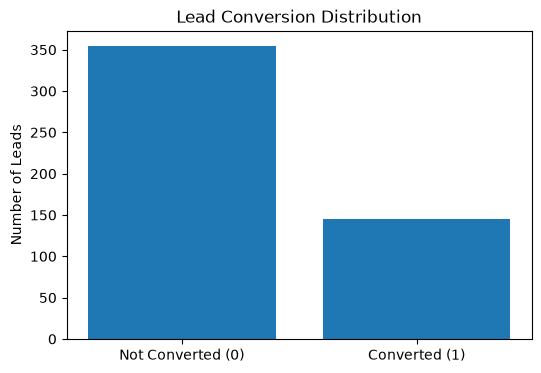

In [22]:

print("Statistical Summary:")
display(df.describe(include="all"))

conversion_counts = df["converted"].value_counts().sort_index()
conversion_rate = df["converted"].mean() * 100

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")
display(conversion_counts)

plt.figure(figsize=(6, 4))
plt.bar(["Not Converted (0)", "Converted (1)"], conversion_counts.values)
plt.title("Lead Conversion Distribution")
plt.ylabel("Number of Leads")
plt.show()


,count,mean,conversion_rate_percent
industry,,,
Education,47,0.361702,36.170213
Healthcare,52,0.326923,32.692308
E-commerce,49,0.326531,32.653061
Manufacturing,46,0.326087,32.608696
Professional Services,53,0.320755,32.075472
CA/Accounting,42,0.309524,30.952381
Logistics,47,0.297872,29.787234
Retail,54,0.296296,29.629630
Real Estate,51,0.235294,23.529412


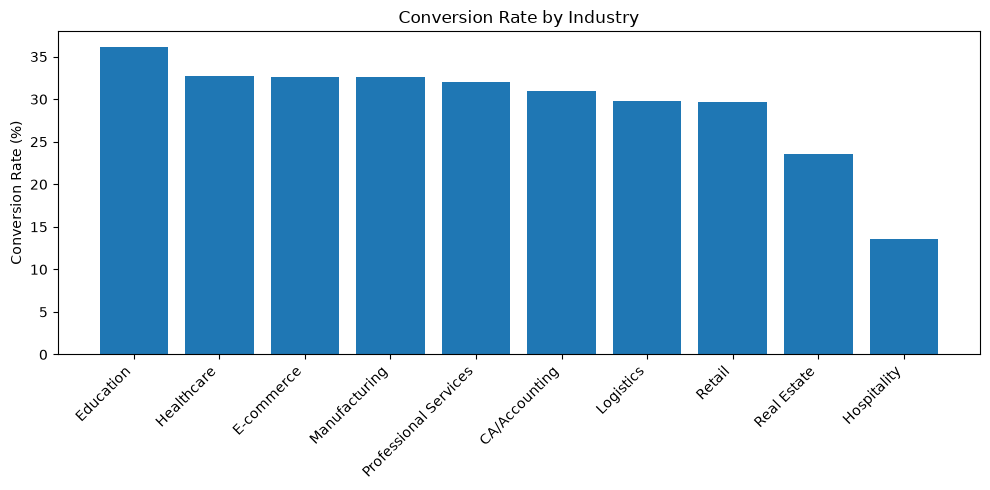

In [23]:

# Conversion rate by industry
industry_conversion = (
    df.groupby("industry")["converted"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

industry_conversion["conversion_rate_percent"] = industry_conversion["mean"] * 100
display(industry_conversion)

plt.figure(figsize=(10, 5))
plt.bar(industry_conversion.index, industry_conversion["conversion_rate_percent"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Industry")
plt.tight_layout()
plt.show()


,count,mean,conversion_rate_percent
lead_source,,,
Referral,67,0.477612,47.761194
Website,71,0.366197,36.619718
Email,78,0.282051,28.205128
WhatsApp,77,0.259740,25.974026
LinkedIn,56,0.250000,25.000000
Instagram,70,0.214286,21.428571
Cold Outreach,81,0.197531,19.753086


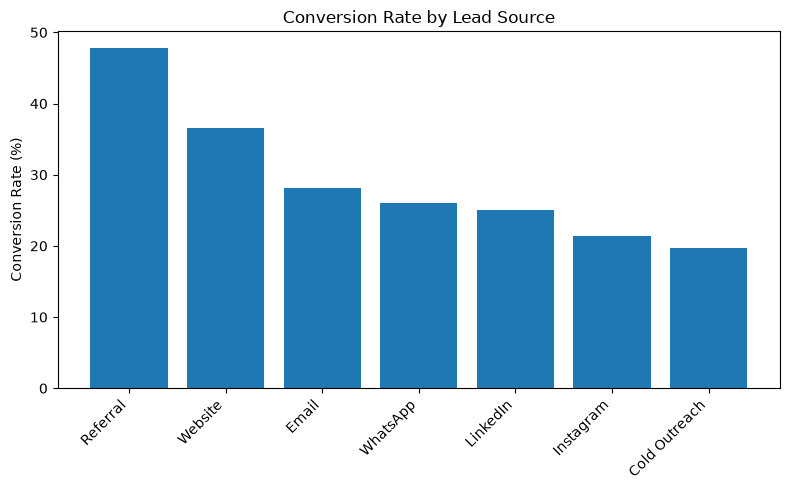

In [24]:

# Conversion rate by lead source
source_conversion = (
    df.groupby("lead_source")["converted"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

source_conversion["conversion_rate_percent"] = source_conversion["mean"] * 100
display(source_conversion)

plt.figure(figsize=(8, 5))
plt.bar(source_conversion.index, source_conversion["conversion_rate_percent"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Lead Source")
plt.tight_layout()
plt.show()


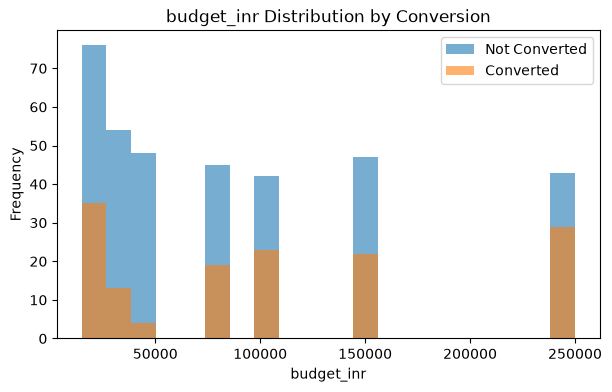

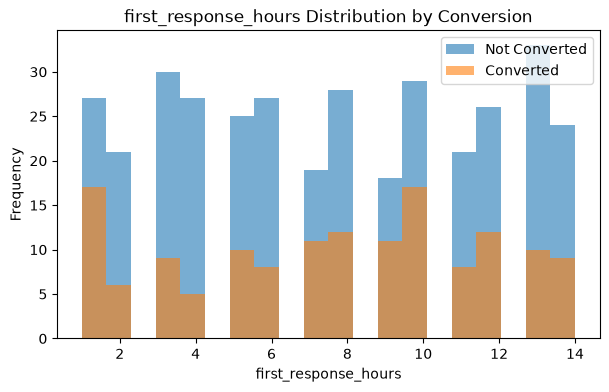

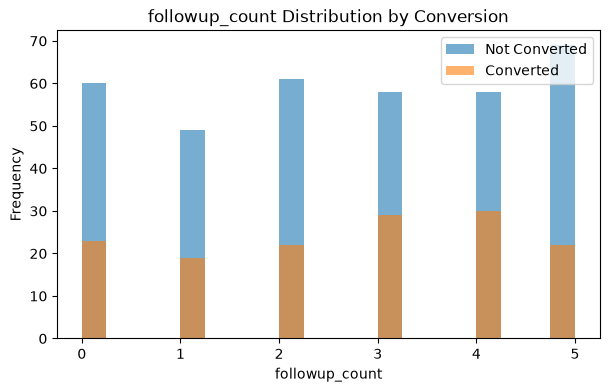

In [25]:

# Numeric feature comparison
numeric_features = ["budget_inr", "first_response_hours", "followup_count"]

for feature in numeric_features:
    plt.figure(figsize=(7, 4))
    data0 = df.loc[df["converted"] == 0, feature]
    data1 = df.loc[df["converted"] == 1, feature]

    plt.hist(data0, bins=20, alpha=0.6, label="Not Converted")
    plt.hist(data1, bins=20, alpha=0.6, label="Converted")
    plt.title(f"{feature} Distribution by Conversion")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()



## 5. Feature Selection and Data Leakage Prevention

The following columns are used as prediction features:

- `industry`
- `service`
- `lead_source`
- `budget_inr`
- `first_response_hours`
- `followup_count`

Excluded columns:

- `lead_id`: Identifier, not a meaningful predictive feature.
- `days_to_conversion`: Known only after conversion for converted leads, so using it would leak future information into the model.


In [26]:

FEATURES = [
    "industry",
    "service",
    "lead_source",
    "budget_inr",
    "first_response_hours",
    "followup_count"
]

TARGET = "converted"

X = df[FEATURES].copy()
y = df[TARGET].copy()

categorical_features = [
    "industry",
    "service",
    "lead_source"
]

numerical_features = [
    "budget_inr",
    "first_response_hours",
    "followup_count"
]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nClass Distribution:")
display(y.value_counts(normalize=True).rename("proportion"))


Feature Matrix Shape: (500, 6)
Target Shape: (500,)

Class Distribution:


converted
0    0.71
1    0.29
Name: proportion, dtype: float64

## 6. Train/Test Split

In [27]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 400
Testing Samples: 100


## 7. Build Preprocessing Pipeline

In [28]:

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.


## 8. Train Multiple Machine Learning Models

In [29]:

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = {}
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    trained_pipelines[model_name] = pipeline
    logging.info("%s trained successfully.", model_name)

results_df = pd.DataFrame(results).T.sort_values(
    by="roc_auc",
    ascending=False
)

display(results_df)


,accuracy,precision,recall,f1_score,roc_auc
Logistic Regression,0.53,0.304348,0.482759,0.373333,0.524041
Random Forest,0.56,0.272727,0.310345,0.290323,0.484216
Gradient Boosting,0.61,0.222222,0.137931,0.170213,0.462846


## 9. Select Best Model

In [30]:

best_model_name = results_df.index[0]
best_pipeline = trained_pipelines[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Best ROC-AUC Score: {results_df.loc[best_model_name, 'roc_auc']:.4f}")

logging.info(
    "Best model selected: %s with ROC-AUC: %.4f",
    best_model_name,
    results_df.loc[best_model_name, "roc_auc"]
)


Best Model: Logistic Regression
Best ROC-AUC Score: 0.5240


## 10. Evaluate Best Model

Classification Report:

              precision    recall  f1-score   support

           0     0.7222    0.5493    0.6240        71
           1     0.3043    0.4828    0.3733        29

    accuracy                         0.5300       100
   macro avg     0.5133    0.5160    0.4987       100
weighted avg     0.6010    0.5300    0.5513       100

Confusion Matrix:


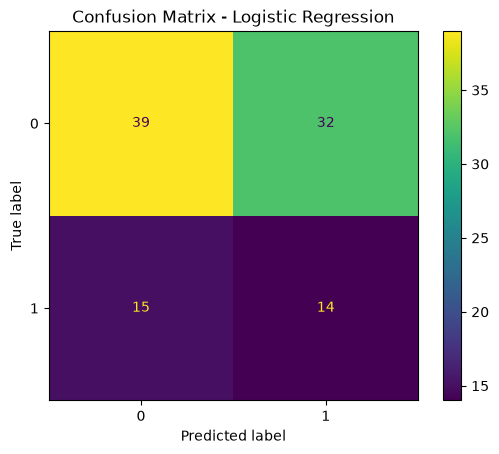

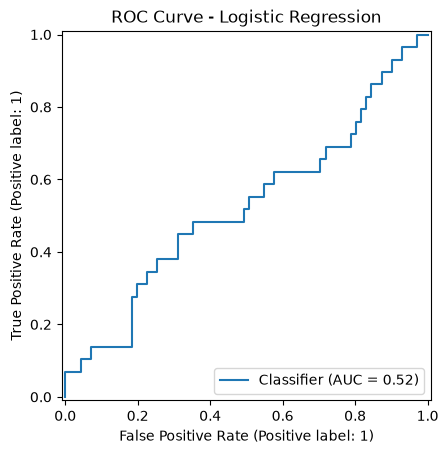

In [31]:

y_pred_best = best_pipeline.predict(X_test)
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best, digits=4))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_best)
plt.title(f"ROC Curve - {best_model_name}")
plt.show()


## 11. Feature Importance / Model Explainability

,feature,importance
7,cat__industry_Hospitality,0.924465
25,cat__lead_source_Referral,0.866746
19,cat__service_Training/Courses,0.819293
13,cat__service_AI/ML Solution,0.788467
20,cat__service_Website Development,0.626815
21,cat__lead_source_Cold Outreach,0.595432
27,cat__lead_source_WhatsApp,0.462480
14,cat__service_Automation,0.461782
26,cat__lead_source_Website,0.436579
6,cat__industry_Healthcare,0.408688


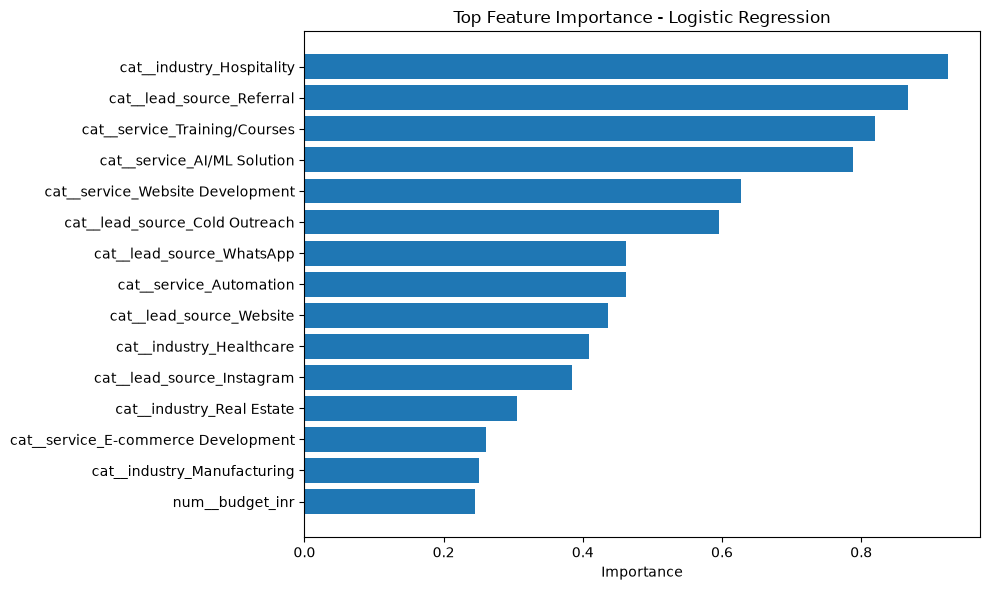

In [32]:

# Extract transformed feature names
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
model = best_pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
elif hasattr(model, "coef_"):
    importance_values = np.abs(model.coef_[0])
else:
    importance_values = None

if importance_values is not None:
    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importance_values
        })
        .sort_values("importance", ascending=False)
        .head(15)
    )

    display(importance_df)

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df["feature"][::-1],
        importance_df["importance"][::-1]
    )
    plt.xlabel("Importance")
    plt.title(f"Top Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not directly available for this model.")


## 12. Lead Prediction Function

In [33]:

def get_priority(probability: float) -> str:
    """Convert conversion probability into a sales priority level."""
    if probability >= 0.80:
        return "HIGH"
    elif probability >= 0.50:
        return "MEDIUM"
    return "LOW"


def predict_lead(lead_data: dict, model_pipeline=best_pipeline) -> dict:
    """Predict lead conversion probability and sales priority."""

    required_features = set(FEATURES)
    provided_features = set(lead_data.keys())

    missing = required_features - provided_features
    if missing:
        raise ValueError(f"Missing required features: {sorted(missing)}")

    input_df = pd.DataFrame([lead_data])

    # Basic input validation
    for column in ["budget_inr", "first_response_hours", "followup_count"]:
        if input_df[column].iloc[0] < 0:
            raise ValueError(f"{column} cannot be negative.")

    probability = float(
        model_pipeline.predict_proba(input_df[FEATURES])[:, 1][0]
    )

    prediction = int(probability >= 0.50)

    return {
        "conversion_prediction": prediction,
        "conversion_probability": round(probability, 4),
        "conversion_percentage": round(probability * 100, 2),
        "lead_priority": get_priority(probability)
    }


# Example prediction
sample_lead = {
    "industry": "Retail",
    "service": df["service"].iloc[0],
    "lead_source": df["lead_source"].iloc[0],
    "budget_inr": 500000,
    "first_response_hours": 2,
    "followup_count": 4
}

prediction_result = predict_lead(sample_lead)
prediction_result


{'conversion_prediction': 1,
 'conversion_probability': 0.887,
 'conversion_percentage': 88.7,
 'lead_priority': 'HIGH'}

## 13. Batch Prediction and Sales Prioritization

In [34]:

def batch_predict(leads_df: pd.DataFrame, model_pipeline=best_pipeline) -> pd.DataFrame:
    """Predict conversion probability for multiple leads."""

    missing_columns = set(FEATURES) - set(leads_df.columns)
    if missing_columns:
        raise ValueError(
            f"Input dataframe is missing columns: {sorted(missing_columns)}"
        )

    output = leads_df.copy()

    probabilities = model_pipeline.predict_proba(output[FEATURES])[:, 1]

    output["conversion_probability"] = probabilities
    output["conversion_percentage"] = probabilities * 100
    output["lead_priority"] = output[
        "conversion_probability"
    ].apply(get_priority)

    output["predicted_conversion"] = (
        output["conversion_probability"] >= 0.50
    ).astype(int)

    return output.sort_values(
        by="conversion_probability",
        ascending=False
    )


lead_priorities = batch_predict(X)

display(
    lead_priorities[
        FEATURES + [
            "conversion_percentage",
            "lead_priority",
            "predicted_conversion"
        ]
    ].head(10)
)


,industry,service,lead_source,budget_inr,first_response_hours,followup_count,conversion_percentage,lead_priority,predicted_conversion
195,Healthcare,Training/Courses,Referral,250000,1,5,94.325956,HIGH,1
436,Manufacturing,Training/Courses,Referral,250000,10,5,91.661568,HIGH,1
133,Retail,Website Development,Referral,250000,3,4,90.829740,HIGH,1
299,Education,Website Development,Referral,250000,10,5,89.925008,HIGH,1
180,Retail,Training/Courses,Referral,100000,4,0,86.379674,HIGH,1
490,Education,Training/Courses,Referral,25000,1,3,86.235174,HIGH,1
175,Education,Training/Courses,Website,100000,1,4,84.310217,HIGH,1
343,Retail,Data Analytics,Referral,250000,6,1,83.673841,HIGH,1
305,Manufacturing,Training/Courses,Website,100000,3,2,82.977523,HIGH,1
229,Education,Website Development,Referral,100000,11,2,82.904545,HIGH,1


## 14. Save Trained Model

In [35]:

MODEL_PATH = "models/lead_conversion_model.joblib"

model_artifact = {
    "model": best_pipeline,
    "features": FEATURES,
    "model_name": best_model_name,
    "metrics": results_df.loc[best_model_name].to_dict()
}

joblib.dump(model_artifact, MODEL_PATH)

print(f"Model saved successfully to: {MODEL_PATH}")
logging.info("Model saved to %s", MODEL_PATH)


Model saved successfully to: models/lead_conversion_model.joblib


## 15. Load Saved Model and Test It

In [36]:

loaded_artifact = joblib.load(MODEL_PATH)

loaded_model = loaded_artifact["model"]

test_probability = loaded_model.predict_proba(
    X_test.head(1)
)[:, 1][0]

print("Loaded Model Name:", loaded_artifact["model_name"])
print("Sample Conversion Probability:", round(test_probability * 100, 2), "%")
print("Saved Metrics:")
display(pd.Series(loaded_artifact["metrics"]))


Loaded Model Name: Logistic Regression
Sample Conversion Probability: 55.95 %
Saved Metrics:


accuracy     0.530000
precision    0.304348
recall       0.482759
f1_score     0.373333
roc_auc      0.524041
dtype: float64